In [2]:
from ssod.apis.inference import init_detector, inference_detector, save_result
import matplotlib.pyplot as plt
import mmcv
import numpy as np
import scipy.io as sio
import os
import scipy
from scipy.optimize import linear_sum_assignment
import re
import pandas as pd
import cv2

In [3]:
num_classes = 6
model = init_detector( config = "/rsrch5/home/trans_mol_path/cercan/data/BE/cell_detect/acformer/finetune/output/worked_cfg.py",
                        checkpoint = "/rsrch5/home/trans_mol_path/cercan/data/BE/cell_detect/acformer/finetune/output/epoch_21.pth")


model.inference_on = "globals"


/App/ACFormer/ssod/models/global_local_stn_sequence_plus.py:71: UserWarning: nn.init.uniform is now deprecated in favor of nn.init.uniform_.
  torch.nn.init.uniform(m.weight, a=-0.1, b=0.1)


load checkpoint from local path: /rsrch5/home/trans_mol_path/cercan/data/BE/cell_detect/acformer/finetune/output/epoch_21.pth


In [4]:
val_folder = "/rsrch5/home/trans_mol_path/cercan/data/BE/cell_detect/acformer/finetune/qpproj/finetuning/validation"

val_roi_folder = os.path.join(val_folder,"roi")
val_roi_files = os.listdir(val_roi_folder)
output_folder = os.path.join(val_folder,"predictions")
os.makedirs(output_folder, exist_ok=True)

In [6]:
class_colors = {
    1: [255, 0, 255],
    2: [0, 255, 0],
    3: [0, 0, 255],
    4: [0, 255, 255],
    5: [255, 0, 0],
    6: [255, 255, 0]
}

class_names = {
   'neutrophil':1,
   'epithelium':2,
   'lymphocyte':3,
   'plasma':4,
   'eosinophil':5,
   'stroma':6}

In [7]:
model.CLASSES

('Neutrophil',
 'Epithelial',
 'Lymphocyte',
 'Plasma',
 'Eosinophil',
 'Connective')

In [147]:
def plot_predictions(tile_path, df1, df2, df3, titles):

    # Load the tile image
    tile_image = cv2.imread(tile_path)
    tile_image = cv2.cvtColor(tile_image, cv2.COLOR_BGR2RGB)

    # Define a function to overlay predictions on the tile image
    def overlay_predictions(tile_image, df):
        class_colors = {
        1: [255, 0, 255],
        2: [0, 255, 0],
        3: [0, 0, 255],
        4: [0, 255, 255],
        5: [255, 0, 0],
        6: [255, 255, 0]
        }

        for _, row in df.iterrows():
            color = class_colors[row['class']]
            x, y = int(row['x']), int(row['y'])
            tile_image = cv2.circle(tile_image, (x, y), radius=5, color=color, thickness=-1)
            
        return tile_image

    # Define the colors for each model

    # Create a figure with 4 subplots
    fig, axs = plt.subplots(2, 2, figsize=(10, 10))

    # Plot the raw image in the first subplot
    axs[0, 0].imshow(tile_image)
    axs[0, 0].set_title('Raw Image')

    axs[0, 0].get_xaxis().set_visible(False)
    axs[0, 0].get_yaxis().set_visible(False)

    # Overlay predictions of each model on the tile image and plot in the remaining subplots
    for i, df in enumerate([df1, df2, df3]):
        ax = axs[(i+1)//2, (i+1)%2]
        ax.imshow(overlay_predictions(tile_image.copy(), df))
        ax.set_title(titles[i])
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    # Show the plot
    plt.show()

In [33]:
pretrained_model = init_detector( config = "/rsrch5/home/trans_mol_path/cercan/data/acformer/checkpoints/lizard/ACFormer_Lizard.py",
                        checkpoint = "/rsrch5/home/trans_mol_path/cercan/data/acformer/checkpoints/lizard/ACFormer_Lizard_BL_AAT_GL.pth")


pretrained_model.inference_on = "globals"

/App/ACFormer/ssod/models/global_local_stn_sequence_plus.py:71: UserWarning: nn.init.uniform is now deprecated in favor of nn.init.uniform_.
  torch.nn.init.uniform(m.weight, a=-0.1, b=0.1)


load checkpoint from local path: /rsrch5/home/trans_mol_path/cercan/data/acformer/checkpoints/lizard/ACFormer_Lizard_BL_AAT_GL.pth
The model and loaded state dict do not match exactly

missing keys in source state_dict: norm.weight, norm.bias



In [131]:
#single image pred
tile_path =os.path.join(val_roi_folder,val_roi_files[2])
den_pred = inference_detector(model, tile_path)

In [132]:
thr = 0.3

pred_centroid = []
pred_inst_type = []

for i in range(num_classes):
    classes = den_pred[i][np.where(den_pred[i][:, 2] > thr)]
    classes = classes[:, :2]
    pred_centroid.extend(classes)
    pred_type = np.full((classes.shape[0], 1), i + 1)
    pred_inst_type.extend(pred_type)

tile_data_pred = np.hstack((pred_centroid, pred_inst_type))
tile_data_pred = tile_data_pred.astype(int)

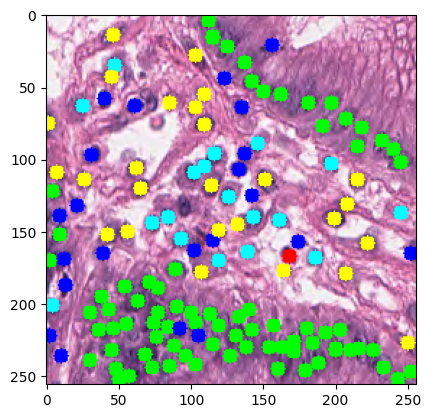

In [133]:
df = pd.DataFrame(tile_data_pred, columns=['x', 'y', 'class'])

tile_image = cv2.imread(tile_path)
tile_image = cv2.cvtColor(tile_image, cv2.COLOR_BGR2RGB)

        
# Overlay each detection
for _, row in df.iterrows():
    color = class_colors[row['class']]
    x, y = int(row['x']), int(row['y'])
    tile_image = cv2.circle(tile_image, (x, y), radius=5, color=color, thickness=-1)
plt.imshow(tile_image)


In [134]:
true_folder = os.path.join(val_folder,"csv")

den_true_path = os.path.join(true_folder,os.path.splitext(val_roi_files[2])[0]+'.csv')

den_true_data = pd.read_csv(den_true_path)
den_true_data['class'] = den_true_data['class'].map(class_names)


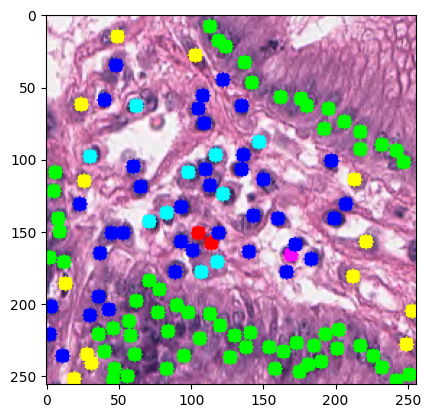

In [135]:
tile_image = cv2.imread(tile_path)
tile_image = cv2.cvtColor(tile_image, cv2.COLOR_BGR2RGB)

        
# Overlay each detection
for _, row in den_true_data.iterrows():
    color = class_colors[row['class']]
    x, y = int(row['x']), int(row['y'])
    tile_image = cv2.circle(tile_image, (x, y), radius=5, color=color, thickness=-1)
plt.imshow(tile_image)

In [139]:
pretrained_den_pred = inference_detector(pretrained_model, tile_path)

/App/ACFormer/thirdparty/mmdetection/mmdet/models/utils/transformer.py:942: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').
  dim_t = temperature ** (2 * (dim_t // 2) / num_pos_feats)
/App/ACFormer/thirdparty/mmdetection/mmdet/models/dense_heads/detr_head_celldet.py:601: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').
  point_index = indexes 

In [140]:

pretrained_pred_centroid = []
pretrained_pred_inst_type = []

for i in range(num_classes):
    classes = pretrained_den_pred[i][np.where(pretrained_den_pred[i][:, 2] > thr)]
    classes = classes[:, :2]
    pretrained_pred_centroid.extend(classes)
    pred_type = np.full((classes.shape[0], 1), i + 1)
    pretrained_pred_inst_type.extend(pred_type)

tile_data_pred_pretrained = np.hstack((pretrained_pred_centroid, pretrained_pred_inst_type))
tile_data_pred_pretrained = tile_data_pred_pretrained.astype(int)

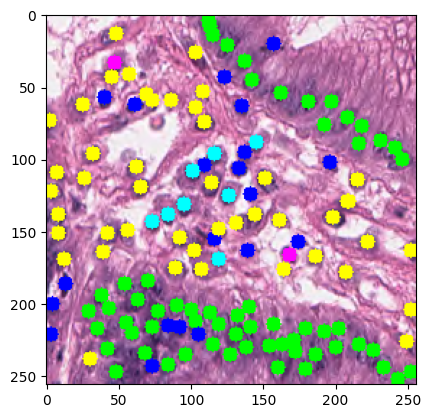

In [141]:
df_pretrained = pd.DataFrame(tile_data_pred_pretrained, columns=['x', 'y', 'class'])

tile_image = cv2.imread(tile_path)
tile_image = cv2.cvtColor(tile_image, cv2.COLOR_BGR2RGB)

        
# Overlay each detection
for _, row in df_pretrained.iterrows():
    color = class_colors[row['class']]
    x, y = int(row['x']), int(row['y'])
    tile_image = cv2.circle(tile_image, (x, y), radius=5, color=color, thickness=-1)
plt.imshow(tile_image)


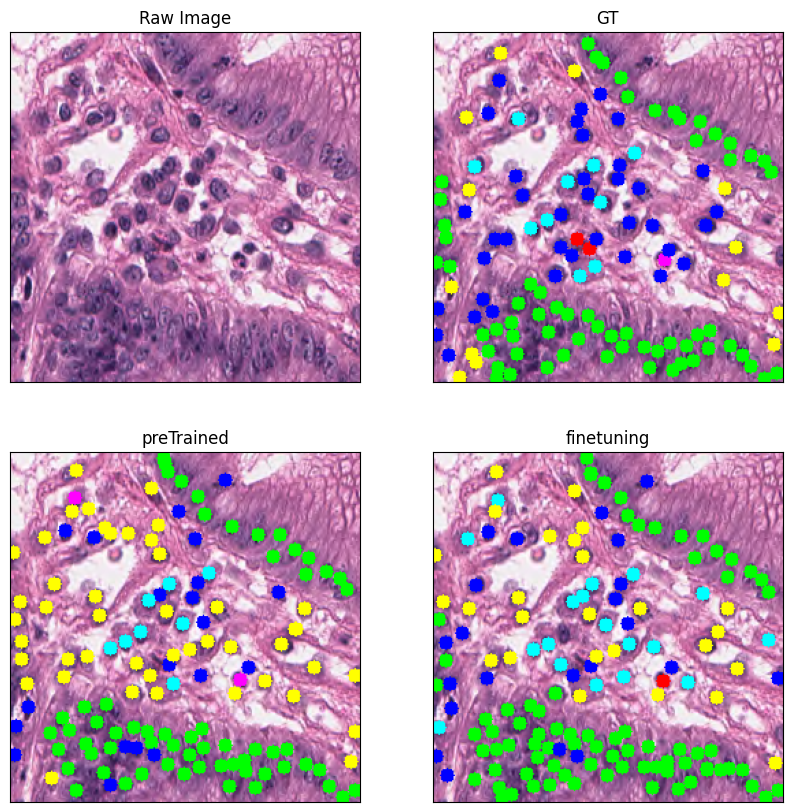

In [148]:
titles = ['GT','preTrained','finetuning']
plot_predictions(tile_path,den_true_data,df_pretrained,df,titles)

# performance calculation

In [18]:
true_centroid_x = (den_true_data["x"]).astype("float32")
true_centroid_y = (den_true_data["y"]).astype("float32")
true_centroid = np.vstack((true_centroid_x, true_centroid_y))
true_inst_type = (den_true_data["inst_type"]).astype("int32")

In [19]:
pred_centroid = np.asarray(pred_centroid).astype("float32")
pred_inst_type = np.asarray(pred_inst_type).astype("int32")

In [20]:
def pair_coordinates(setA, setB, radius):
    """Use the Munkres or Kuhn-Munkres algorithm to find the most optimal
    unique pairing (largest possible match) when pairing points in set B
    against points in set A, using distance as cost function.

    Args:
        setA, setB: np.array (float32) of size Nx2 contains the of XY coordinate
                    of N different points
        radius: valid area around a point in setA to consider
                a given coordinate in setB a candidate for match
    Return:
        pairing: pairing is an array of indices
        where point at index pairing[0] in set A paired with point
        in set B at index pairing[1]
        unparedA, unpairedB: remaining poitn in set A and set B unpaired

    """
    # * Euclidean distance as the cost matrix
    pair_distance = scipy.spatial.distance.cdist(setA, setB, metric='euclidean')

    # * Munkres pairing with scipy library
    # the algorithm return (row indices, matched column indices)
    # if there is multiple same cost in a row, index of first occurence
    # is return, thus the unique pairing is ensured
    indicesA, paired_indicesB = linear_sum_assignment(pair_distance)

    # extract the paired cost and remove instances
    # outside of designated radius
    pair_cost = pair_distance[indicesA, paired_indicesB]

    pairedA = indicesA[pair_cost <= radius]
    pairedB = paired_indicesB[pair_cost <= radius]

    pairing = np.concatenate([pairedA[:, None], pairedB[:, None]], axis=-1)
    unpairedA = np.delete(np.arange(setA.shape[0]), pairedA)
    unpairedB = np.delete(np.arange(setB.shape[0]), pairedB)
    return pairing, unpairedA, unpairedB

In [23]:
true_centroid_array = true_centroid.T
pred_centroid_array = np.squeeze(np.array(pred_centroid))
paired, unpaired_true, unpaired_pred = pair_coordinates(
        true_centroid_array, pred_centroid_array, 6
    )

In [24]:
paired_true_type = true_inst_type[paired[:, 0]]
paired_pred_type = pred_inst_type[paired[:, 1]]
unpaired_true_type = true_inst_type[unpaired_true]
unpaired_pred_type = pred_inst_type[unpaired_pred]

In [25]:
def _f1_type(paired_true, paired_pred, unpaired_true, unpaired_pred, type_id, w):
    type_samples = (paired_true == type_id) | (paired_pred == type_id)

    paired_true = paired_true[type_samples[0]]
    paired_pred = paired_pred[type_samples[0]]

    tp_dt = ((paired_true == type_id) & (paired_pred == type_id)).sum()
    tn_dt = ((paired_true != type_id) & (paired_pred != type_id)).sum()
    fp_dt = ((paired_true != type_id) & (paired_pred == type_id)).sum()
    fn_dt = ((paired_true == type_id) & (paired_pred != type_id)).sum()

    fp_d = (unpaired_pred == type_id).sum()
    fn_d = (unpaired_true == type_id).sum()

    f1_type = (2 * (tp_dt + tn_dt)) / (
            2 * (tp_dt + tn_dt)
            + w[0] * fp_dt
            + w[1] * fn_dt
            + w[2] * fp_d
            + w[3] * fn_d
    )
    return f1_type

In [26]:
w = [1, 1]
tp_d = paired_pred_type.shape[0]
fp_d = unpaired_pred_type.shape[0]
fn_d = unpaired_true_type.shape[0]


In [28]:
names_classes = {value: key for key, value in class_names.items()}

In [29]:

paired_true_type = np.array(paired_true_type)
paired_true_type = np.array(paired_true_type)

tp_tn_dt = (paired_pred_type == paired_true_type).sum()
fp_fn_dt = (paired_pred_type != paired_true_type).sum()

acc_type = tp_tn_dt / (tp_tn_dt + fp_fn_dt)
f1_d = 2 * tp_d / (2 * tp_d + w[0] * fp_d + w[1] * fn_d)

w = [2, 2, 1, 1]

# if type_uid_list is None:
type_uid_list = np.unique(true_inst_type).tolist()

results_list = [f1_d, acc_type]
for type_uid in type_uid_list:
    f1_type = _f1_type(
        paired_true_type,
        paired_pred_type,
        unpaired_true_type,
        unpaired_pred_type,
        type_uid,
        w,
    )
    # results_list.append(f1_type)

    print("F1 Type {}:{}".format(names_classes[type_uid], f1_type))

# np.set_printoptions(formatter={"float": "{: 0.5f}".format})
# results_list = np.array(results_list)

# Avg = 0
# print("\n===========================Evaluation=======================")
# print("Thr: {}".format(thr))
# print("F1 Detection:{}".format(results_list[0]))
# for i in range(num_classes):
#     print("F1 Type{}:{}".format(i, results_list[i + 2]))
#     Avg += results_list[i + 2]
# print("F1c Avg:{}".format(Avg / num_classes))
# print("===========================Evaluation=======================\n")

F1 Type epithelium:0.997036158861885
F1 Type lymphocyte:0.5697039079981266
F1 Type plasma:0.25
F1 Type stroma:0.0


# batch analysis

In [158]:

def print_progress_bar(iteration, total, prefix='', suffix='', decimals=1, length=100, fill='█', print_end="\r"):
    percent = ("{0:." + str(decimals) + "f}").format(100 * (iteration / float(total)))
    filled_length = int(length * iteration // total)
    bar = fill * filled_length + '-' * (length - filled_length)
    print(f'\r{prefix} |{bar}| {percent}% {suffix}', end=print_end)
    if iteration == total:
        print()

# Function to process a batch of tiles
def process_batch(batch_tile_paths, output_folder, model, thr, num_classes):
    batch_results =[]
    batch_results = inference_detector(model, batch_tile_paths)  # Assume inference_detector can handle batches
    for idx, tile_path in enumerate(batch_tile_paths):
        tile_result = batch_results[idx]  # Get the result for the specific tile
        pred_centroid = []
        pred_inst_type = []

        for i in range(num_classes):
            classes = tile_result[i][np.where(tile_result[i][:, 2] > thr)]
            classes = classes[:, :2]
            pred_centroid.extend(classes)
            pred_type = np.full((classes.shape[0], 1), i + 1)
            pred_inst_type.extend(pred_type)

        tile_export_path = os.path.join(output_folder, os.path.basename(tile_path) + '.csv')
        tile_data = np.hstack((pred_centroid, pred_inst_type))
        tile_data = tile_data.astype(int)
        np.savetxt(tile_export_path, tile_data, delimiter=",", fmt='%d')
        batch_results.append(tile_data)
    return batch_results

# Main processing function with batching
def process_images(img_folder, model, output_folder, thr, num_classes, batch_size=256):
    preds = []
    img_list = os.listdir(img_folder)
    for i, tile in enumerate(img_list):
        print("processing: "+ tile)
        # img_output = os.path.join(output_folder, img)
        # os.makedirs(img_output, exist_ok=True)
        # img_folder = os.path.join(images_folder, img)
        os.makedirs(output_folder, exist_ok=True)

        # tiles_list = os.listdir(img_folder)
        
        batch_tile_paths = []

        # for i, tile_name in enumerate(tiles_list):
        print_progress_bar(i + 1, len(img_list), prefix='Predicting tiles:', suffix='Complete', length=50)
        # tile_path = os.path.join(img_folder, tile_name)
        tile_path= os.path.join(img_folder, tile)
        batch_tile_paths.append(tile_path)

        # If batch is full, process it
        if len(batch_tile_paths) == batch_size:
            batch_results = process_batch(batch_tile_paths, output_folder, model, thr, num_classes)
            batch_tile_paths = []  # Clear batch after processing
            preds.extend(batch_results)

    # Process any remaining tiles in the last batch
    if batch_tile_paths:
        batch_results = process_batch(batch_tile_paths, output_folder, model, thr, num_classes)
        preds.extend(batch_results)

    return preds

## run all images together

no batching

In [171]:
def pair_coordinates(setA, setB, radius):
    """Use the Munkres or Kuhn-Munkres algorithm to find the most optimal
    unique pairing (largest possible match) when pairing points in set B
    against points in set A, using distance as cost function.

    Args:
        setA, setB: np.array (float32) of size Nx2 contains the of XY coordinate
                    of N different points
        radius: valid area around a point in setA to consider
                a given coordinate in setB a candidate for match
    Return:
        pairing: pairing is an array of indices
        where point at index pairing[0] in set A paired with point
        in set B at index pairing[1]
        unparedA, unpairedB: remaining poitn in set A and set B unpaired

    """
    # * Euclidean distance as the cost matrix
    pair_distance = scipy.spatial.distance.cdist(setA, setB, metric='euclidean')

    # * Munkres pairing with scipy library
    # the algorithm return (row indices, matched column indices)
    # if there is multiple same cost in a row, index of first occurence
    # is return, thus the unique pairing is ensured
    indicesA, paired_indicesB = linear_sum_assignment(pair_distance)

    # extract the paired cost and remove instances
    # outside of designated radius
    pair_cost = pair_distance[indicesA, paired_indicesB]

    pairedA = indicesA[pair_cost <= radius]
    pairedB = paired_indicesB[pair_cost <= radius]

    pairing = np.concatenate([pairedA[:, None], pairedB[:, None]], axis=-1)
    unpairedA = np.delete(np.arange(setA.shape[0]), pairedA)
    unpairedB = np.delete(np.arange(setB.shape[0]), pairedB)
    return pairing, unpairedA, unpairedB

In [243]:
# def det(args, pred_centroid, pred_inst_type, img_name, img_idx):
def det(pred_centroid,pred_inst_type, tile_true_data):
    # global pred_idx_offset, pred_inst_type_all, unpaired_pred_all, unpaired_true_all, true_idx_offset, true_inst_type_all, paired_all
    # img_path = os.path.join(args.gt_file, img_name + ".mat")
    # true_info = sio.loadmat(img_path)
    # true_centroid = (true_info["inst_centroid"]).astype("float32")
    # true_inst_type = (true_info["inst_type"]).astype("int32")
    true_centroid_x = (tile_true_data["x"]).astype("float32")
    true_centroid_y = (tile_true_data["y"]).astype("float32")
    true_centroid   = np.vstack((true_centroid_x, true_centroid_y))
    true_centroid_array = true_centroid.T
    true_inst_type  = (tile_true_data["class"]).astype("int32")

    # if true_centroid.shape[0] != 0:
    #     true_inst_type = true_inst_type[:, 0]
    # else:  # no instance at all
    #     true_centroid = np.array([[0, 0]])
    #     true_inst_type = np.array([0])

    pred_centroid  = np.asarray(pred_centroid).astype("float32")
    pred_centroid_array = np.squeeze(np.array(pred_centroid))

    pred_inst_type = np.asarray(pred_inst_type).astype("int32")

    # if pred_centroid.shape[0] != 0:
    #     pred_inst_type = pred_inst_type[:, 0]
    # else:  # no instance at all
    #     pred_centroid = np.array([[0, 0]])
    #     pred_inst_type = np.array([0])

    paired, unpaired_true, unpaired_pred = pair_coordinates(
        true_centroid_array, pred_centroid_array, 6
    )

    paired_true_type = true_inst_type[paired[:, 0]]
    paired_pred_type = pred_inst_type[paired[:, 1]]
    unpaired_true_type = true_inst_type[unpaired_true]
    unpaired_pred_type = pred_inst_type[unpaired_pred]

    # true_idx_offset = (
    #     true_idx_offset + true_inst_type_all[-1].shape[0] if img_idx != 0 else 0
    # )
    # pred_idx_offset = (
    #     pred_idx_offset + pred_inst_type_all[-1].shape[0] if img_idx != 0 else 0
    # )
    # true_inst_type_all.append(true_inst_type)
    # pred_inst_type_all.append(pred_inst_type)

    # if paired.shape[0] != 0:  # ! sanity
    #     paired[:, 0] += true_idx_offset
    #     paired[:, 1] += pred_idx_offset
    #     paired_all.append(paired)

    # unpaired_true += true_idx_offset
    # unpaired_pred += pred_idx_offset
    # unpaired_true_all.append(unpaired_true)
    # unpaired_pred_all.append(unpaired_pred)

    return paired_true_type, paired_pred_type, unpaired_true_type, unpaired_pred_type


def f1_type_calculate(paired_true, paired_pred, unpaired_true, unpaired_pred, type_id):
        #these weights penaltisize the undetected cells by twice. 
        w = [2, 2, 1, 1]

        type_samples = (paired_true == type_id) | (paired_pred == type_id)

        paired_true = paired_true[type_samples]
        paired_pred = paired_pred[type_samples]

        tp_dt = ((paired_true == type_id) & (paired_pred == type_id)).sum()
        tn_dt = ((paired_true != type_id) & (paired_pred != type_id)).sum()
        fp_dt = ((paired_true != type_id) & (paired_pred == type_id)).sum()
        fn_dt = ((paired_true == type_id) & (paired_pred != type_id)).sum()

        fp_d = (unpaired_pred == type_id).sum()
        fn_d = (unpaired_true == type_id).sum()

        f1_type = (2 * (tp_dt + tn_dt)) / (
                2 * (tp_dt + tn_dt)
                + w[0] * fp_dt
                + w[1] * fn_dt
                + w[2] * fp_d
                + w[3] * fn_d
        )
        return f1_type


def calculate_metrics(paired_true_type, paired_pred_type, unpaired_true_type, unpaired_pred_type):
    tp_d = paired_pred_type.shape[0]
    fp_d = unpaired_pred_type.shape[0] 
    fn_d = unpaired_true_type.shape[0] 

    tp_tn_dt = (paired_true_type == np.squeeze(paired_pred_type) ).sum()
    fp_fn_dt = (np.squeeze(paired_pred_type) != paired_true_type).sum()

    acc_type = tp_tn_dt / (tp_tn_dt + fp_fn_dt)
    f1_d = 2 * tp_d / (2 * tp_d +  fp_d +  fn_d)
    results_list = [f1_d, acc_type]
    type_uid_list = np.unique(true_inst_type).tolist()
    for class_code in range(num_classes):
        if class_code in type_uid_list:
            f1_type = f1_type_calculate(paired_true_type, np.squeeze(paired_pred_type), unpaired_true_type, unpaired_pred_type, class_code)
            results_list.append(f1_type)
        else:
            results_list.append('NA')
    
    return results_list

In [254]:

def tile_data_convert(tile_result,thr=0.5, num_classes =6):
        pred_centroid   = []
        pred_inst_type  = []

        for i in range(num_classes):
            classes = tile_result[i][np.where(tile_result[i][:, 2] > thr)]
            classes = classes[:, :2]
            pred_centroid.extend(classes)
            pred_type = np.full((classes.shape[0], 1), i + 1)
            pred_inst_type.extend(pred_type)
        tile_data = np.hstack((pred_centroid, pred_inst_type))
        tile_data = tile_data.astype(int)
        return tile_data, pred_centroid, pred_inst_type

In [262]:

paired_true_type_all   = [] 
paired_pred_type_all   = [] 
unpaired_true_type_all = [] 
unpaired_pred_type_all = []
thr= 0.5

for idx, img in enumerate(val_roi_files):
    tile_path= os.path.join(val_roi_folder, img)

    tile_pred = inference_detector(model, tile_path)
    tile_pred_data, pred_centroid, pred_inst_type = tile_data_convert(tile_pred , thr)
    
    tile_pred_df = pd.DataFrame(tile_pred_data, columns=['x', 'y', 'class'])

    # save to csv
    csv_path = os.path.join(output_folder, os.path.basename(tile_path) + '.csv')
    np.savetxt(csv_path, tile_pred_data, delimiter=",", fmt='%d')
    # calculate f1, accuracy for all classes

    tile_true_path = os.path.join(true_folder,os.path.splitext(img)[0]+'.csv')

    tile_true_data = pd.read_csv(tile_true_path)
    tile_true_data['class'] = tile_true_data['class'].map(class_names)

    paired_true_type, paired_pred_type, unpaired_true_type, unpaired_pred_type = det(pred_centroid,pred_inst_type, tile_true_data)


    paired_true_type_all.append(paired_true_type)
    paired_pred_type_all.append(paired_pred_type)
    unpaired_true_type_all.append(unpaired_true_type)
    unpaired_pred_type_all.append(unpaired_pred_type)


results_list = calculate_metrics(paired_true_type_all[0], paired_pred_type_all[0], unpaired_true_type_all[0], unpaired_pred_type_all[0])



/App/ACFormer/thirdparty/mmdetection/mmdet/models/utils/transformer.py:942: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').
  dim_t = temperature ** (2 * (dim_t // 2) / num_pos_feats)
/App/ACFormer/thirdparty/mmdetection/mmdet/models/dense_heads/detr_head_celldet.py:601: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').
  point_index = indexes 

In [263]:
Avg = 0
detected_classes = 0
names_classes = {value: key for key, value in class_names.items()}
print("\n===========================Evaluation=======================")
print("Thr: {}".format(thr))
print("F1 Detection:{}".format(results_list[0]))
print("Accuract:{}".format(results_list[1]))
for i in range(num_classes):
    if results_list[i + 2] != 'NA':
        print("F1 {}:{}".format(names_classes[i], results_list[i + 2]))
        Avg += results_list[i + 2]
        detected_classes += 1
print("F1c Avg:{}".format(Avg / detected_classes))
print("===========================Evaluation=======================\n")


===========================Evaluation=======================
Thr: 0.5
F1 Detection:0.711864406779661
Accuract:0.9682539682539683
F1 epithelium:0.8264462809917356
F1 lymphocyte:0.40816326530612246
F1 plasma:1.0
F1c Avg:0.7448698487659526
===========================Evaluation=======================



In [275]:
Avg = 0
detected_classes = 0
names_classes = {value: key for key, value in class_names.items()}
print("\n==========Evaluation==========")
print("Threshold: {}".format(thr))
print("F1 Detection:{0:.3f}".format(results_list[0]))
print("Accuracy:{0:.3f}".format(results_list[1]))
for i in range(num_classes):
    if results_list[i + 2] != 'NA':
        print("F1 {}:{:.3f}".format(names_classes[i], results_list[i + 2]))
        Avg += results_list[i + 2]
        detected_classes += 1
print("F1c Avg:{0:.3f}".format(Avg / detected_classes))
# print("==========Evaluation==========\n")


==========Evaluation==========
Threshold: 0.5
F1 Detection:0.712
Accuracy:0.968
F1 epithelium:0.826
F1 lymphocyte:0.408
F1 plasma:1.000
F1c Avg:0.745
